<a href="https://colab.research.google.com/github/Demosthene-OR/Student-AI-and-Data-Management/blob/main/80_GTI_3A_Intro_to_Data_Science_with_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://prof.totalenergies.com/wp-content/uploads/2024/09/TotalEnergies_TPA_picto_DegradeRouge_RVB-1024x1024.png" height="150" width="150">
<hr style="border-width:2px;border-color:#75DFC1">
<h1 style = "text-align:center" > Exercises Introduction to Data Science with Python </h1> 
<h2 style = "text-align:center"> Teacher: Olivier Renouard </h2> 
<hr style="border-width:2px;border-color:#75DFC1">

### Student: put your name here

### Keyboard Shortcuts
Learning the keyboard shortcuts is an important process to become faster at manipulating any notebook. Here are a few shortcuts for you to start learning today:

In command mode, press:

* A to insert a cell Above the current cell
* B to insert a cell Below the current cell
* ↩ (read Enter key) or double click to enter in edit mode
* ↑/↓ (read Up/Down arrow) to navigate cells

In edit mode, press:

* Esc to enter command mode (i.e. exit edit mode)
* ⇧-↩ (read Shift Enter) to run the code, create a new cell below and enter edit mode in that new cell

## Loading libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sklearn as sklearn

# 1. Visualizing data using an US Oil and Gas Production Dataset
Analysing the [Kaggle Dataset](https://www.kaggle.com/djzurawski/us-oil-and-gas-production-june-2008-to-june-2018) with information about Oil and Gas production in the US from June 2008 to June 2018.

Analyse data with [pandas](https://pandas.pydata.org/) and plot with [matplotlib](https://matplotlib.org/)

In [2]:
# insert the libraries here and run the code
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

Loading the Gas production

Go to the files menu and import the csv files for this exercise

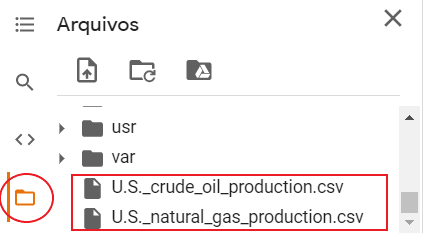


```
file = "/U.S._natural_gas_production.csv"  => file name
gas_df = pd.read_csv(file, decimal=",") => or put the file name with its path directly in the (' ')
```


In [3]:
# from google.colab import files
# import io
# uploaded = files.upload()

In [4]:
# your code here
url = "https://raw.githubusercontent.com/Demosthene-OR/Student-AI-and-Data-Management/main/data_80/"
file = "ex01_U.S._natural_gas_production.csv" 
gas_df = pd.read_csv(url+file, decimal=",")

Displaying the first rows to check the dataset


```
gas_df.head(n)
```
n being the number of rows you want to show


In [5]:
# your code here
gas_df.head(10)

,Month,U.S.,Alaska,Arkansas,Kansas,Other States,Federal Offshore--Gulf of Mexico,Wyoming,West Virginia,Utah,Pennsylvania,Texas,Oklahoma,Ohio,North Dakota,New Mexico,Montana,Louisiana,Colorado,California
0,2008-06-01,70626,8875,1196,1024,2995,7339,6839,670,1198,540,21446,5241,224,243,3975,323,3989,3576,932
1,2008-07-01,71137,8375,1256,1034,3150,7468,6940,674,1200,512,21547,5256,220,243,4179,324,4008,3834,919
2,2008-08-01,70760,8739,1313,1033,3092,6868,6835,678,1277,529,21777,4896,220,249,4092,327,3896,4056,881
3,2008-09-01,63984,9221,1316,1032,2953,2100,6447,657,1276,542,20435,5224,224,260,4069,330,2960,4049,890
4,2008-10-01,69464,9674,1375,1026,3113,4368,6909,692,1241,543,21948,5126,236,267,4168,330,3718,3860,870
5,2008-11-01,71662,9876,1422,1092,3311,5297,7126,681,1275,524,22218,5145,245,269,4078,326,3916,3978,882
6,2008-12-01,71840,9972,1517,988,3064,5672,7297,657,1259,569,22112,5318,248,242,3957,302,3802,3998,866
7,2009-01-01,72643,9533,1605,1009,3006,6351,7067,679,1273,783,22211,5322,254,241,3968,304,3829,4330,876
8,2009-02-01,74077,10007,1627,1018,3280,6635,7220,695,1289,832,22025,5433,251,243,4063,311,3925,4353,871
9,2009-03-01,72983,9594,1679,994,2901,6726,7135,712,1300,758,22007,5262,245,245,4018,305,3941,4298,864


Analyze the dataset


```
gas_df.shape
```


```
gas_df.columns
```


```
gas_df.dtypes[0:2] # Checking the types of the first two columns.
```


In [6]:
# your code here
gas_df.shape

(121, 20)

In [7]:
# your code here
gas_df.columns

Index(['Month', 'U.S.', 'Alaska', 'Arkansas', 'Kansas', 'Other States',
       'Federal Offshore--Gulf of Mexico', 'Wyoming', 'West Virginia', 'Utah',
       'Pennsylvania', 'Texas', 'Oklahoma', 'Ohio', 'North Dakota',
       'New Mexico', 'Montana', 'Louisiana', 'Colorado', 'California'],
      dtype='object')

In [8]:
# your code here
gas_df.dtypes[0:2]

Month    object
U.S.      int64
dtype: object

Let's group the months of each year

In [9]:
gas_df['Month'] = pd.to_datetime(gas_df['Month'], format='%Y-%m-%d')
gas_df.head(3)

,Month,U.S.,Alaska,Arkansas,Kansas,Other States,Federal Offshore--Gulf of Mexico,Wyoming,West Virginia,Utah,Pennsylvania,Texas,Oklahoma,Ohio,North Dakota,New Mexico,Montana,Louisiana,Colorado,California
0,2008-06-01,70626,8875,1196,1024,2995,7339,6839,670,1198,540,21446,5241,224,243,3975,323,3989,3576,932
1,2008-07-01,71137,8375,1256,1034,3150,7468,6940,674,1200,512,21547,5256,220,243,4179,324,4008,3834,919
2,2008-08-01,70760,8739,1313,1033,3092,6868,6835,678,1277,529,21777,4896,220,249,4092,327,3896,4056,881


In [10]:
yearly_gas_df = gas_df.groupby(gas_df['Month'].dt.year).sum(numeric_only=True)
yearly_gas_df

,U.S.,Alaska,Arkansas,Kansas,Other States,Federal Offshore--Gulf of Mexico,Wyoming,West Virginia,Utah,Pennsylvania,Texas,Oklahoma,Ohio,North Dakota,New Mexico,Montana,Louisiana,Colorado,California
Month,,,,,,,,,,,,,,,,,,,
2008,489473,64732,9395,7229,21678,39112,48393,4709,8726,3759,151483,36206,1617,1773,28518,2262,26289,27351,6240
2009,856876,108986,22353,11689,36078,80346,83413,8692,14782,9009,251694,62535,2919,3040,46867,3463,51221,49716,10071
2010,881622,105219,30475,10708,37542,74309,82687,8718,14361,18771,249632,60074,2568,3741,44101,3068,72873,52259,10521
2011,936163,104154,35384,10191,38187,60213,78095,12948,15170,43014,260747,62075,2592,5155,42315,2615,99905,54215,9181
2012,968632,103856,37571,9714,37045,50102,72988,17694,16079,73950,266989,66337,2772,8473,41846,2197,96895,56037,8092
2013,970617,105776,37466,9613,22657,43647,67338,24363,15482,107076,272844,65524,5442,11362,41010,2078,77873,52769,8296
2014,1032439,104298,36917,9415,20761,41937,65709,35055,14946,139932,284598,76643,16803,15214,41631,1947,64746,54021,7861
2015,1082158,104447,33221,9349,20102,42979,65615,43236,13717,158236,289330,82166,33069,19211,42638,1916,59621,55521,7786
2016,1070085,105900,26999,7984,18722,39990,60613,45077,11958,174225,266713,80932,47199,19964,42120,1710,57459,55791,6723


Plot a graph of the yearly production

Text(0.5, 0, 'Year')

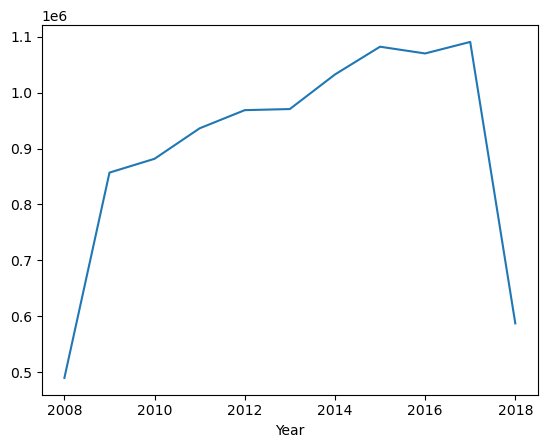

In [11]:

plot = yearly_gas_df['U.S.'].plot()
plot.set_xlabel("Year")

Change the color of the graph using "color=red" as as parameter of the plot() function

Text(0.5, 0, 'Year')

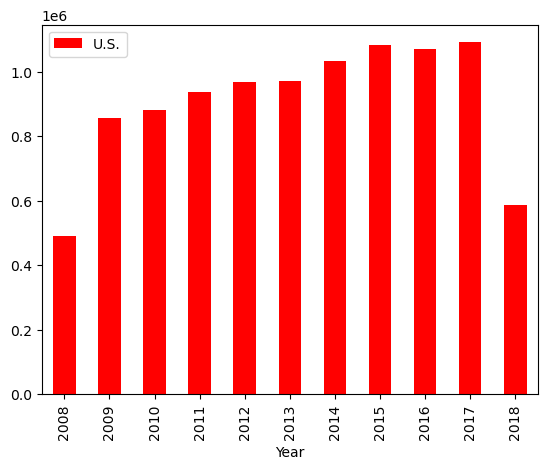

In [12]:
plot = yearly_gas_df.filter(items=['U.S.']).plot(kind="bar", color="red")
plot.set_xlabel("Year")

### Do the same thing for the Crude dataset

In [13]:
#Chargement du fichier
url = "https://raw.githubusercontent.com/Demosthene-OR/Student-AI-and-Data-Management/main/data_80/"
file = "ex01_U.S._crude_oil_production.csv" 
fileCrude= url+file

oil_df=pd.read_csv(fileCrude,delimiter=',')

#On montre les 5 premières lignes pour regarder l'aspect du tableau
oil_df.head(5)

#Impression de la forme du dataset
print("Forme du dataset :", oil_df.shape)

#Impression du nom des colonnes du dataset (+ type)
print("Nom des colonnes :")
print(oil_df.columns)

#Impression du type des deux premières colonnes
oil_df.dtypes[0:2]

Forme du dataset : (121, 36)
Nom des colonnes :
Index(['Month', 'U.S. Crude Oil ', 'Alabama', 'Alaska', 'Arkansas', 'Arizona',
       'California', 'Colorado', 'Federal Offshore Gulf of Mexico Crude Oil',
       'Federal Offshore Pacific Crude Oil', 'Florida', 'Idaho', 'Illinois',
       'Indiana', 'Kansas', 'Kentucky', 'Louisiana', 'Michigan', 'Mississippi',
       'Missouri', 'Nebraska', 'Montana', 'Nevada', 'New Mexico', 'New York',
       'North Dakota', 'Ohio', 'Oklahoma', 'Pennsylvania', 'South Dakota',
       'Wyoming', 'West Virginia', 'Virginia', 'Utah', 'Texas', 'Tennessee'],
      dtype='object')


Month              object
U.S. Crude Oil      int64
dtype: object

In [14]:
#Ecriture des dates
oil_df['Month'] = pd.to_datetime(oil_df['Month'], format='%Y-%m-%d')
oil_df.head(3)

#Regroupement par années
yearly_oil_df = oil_df.groupby(oil_df['Month'].dt.year).sum(numeric_only=True)
yearly_oil_df

,U.S. Crude Oil,Alabama,Alaska,Arkansas,Arizona,California,Colorado,Federal Offshore Gulf of Mexico Crude Oil,Federal Offshore Pacific Crude Oil,Florida,...,Ohio,Oklahoma,Pennsylvania,South Dakota,Wyoming,West Virginia,Virginia,Utah,Texas,Tennessee
Month,,,,,,,,,,,,,,,,,,,,,
2008,34211,149,4666,118,0,4095,589,7302,465,37,...,98,1286,56,35,1013,39,0,438,7773,7
2009,64180,236,7749,189,0,6815,998,18727,734,24,...,156,2144,96,55,1695,48,0,757,13132,12
2010,65741,234,7199,189,0,6588,1086,18640,713,56,...,156,2239,108,53,1771,59,0,809,14026,12
2011,67829,275,6742,195,0,6449,1295,15805,652,67,...,156,2534,114,53,1795,72,0,864,17393,12
2012,78007,312,6310,214,0,6465,1626,15189,580,71,...,168,3095,144,60,1900,85,0,991,23742,12
2013,89585,342,6182,218,0,6540,2175,15068,610,72,...,264,3786,174,60,2088,237,0,1152,30475,12
2014,105064,323,5958,224,0,6729,3139,16761,608,73,...,495,4605,222,60,2501,340,0,1346,38049,12
2015,113179,318,5796,205,0,6619,4036,18174,378,72,...,876,5484,232,53,2842,380,0,1222,41335,12
2016,105970,266,5874,183,0,6101,3820,19177,201,63,...,705,5102,207,47,2380,251,0,1001,38140,12


Text(0.5, 0, 'Year')

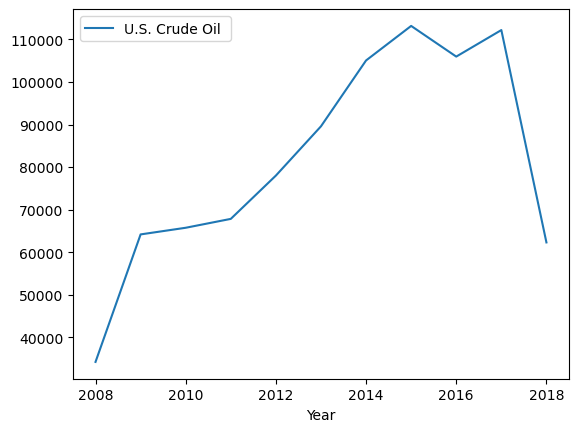

In [15]:
#Graphique de la production totale de gaz aux USA en fonction de l'année
plot = yearly_oil_df.filter(items=['U.S. Crude Oil ']).plot()
plot.set_xlabel("Year")

# 2. Applying Linear Regression for Salary Prediction

We will try to predict salary based on their years of experience.

We will use Linear Regression algorithm to model this probelm.

Let's start by importing the librairies we'll use:


```
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
```

In [16]:
# Importing the libraries

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd



In [17]:
import sklearn
from sklearn.model_selection import train_test_split
from sklearn import linear_model

We will use the dataset Salary_Data.csv

Import this dataset using the function "read_csv" from pandas

dataset = pd.read_csv("..location/Salary_Data.csv")


In [18]:
# Importing the dataset
dataset = pd.read_csv(url+"ex02_Salary_Data.csv",delimiter=',')


1.1 Data Structure

We need to create a small dataset with this data. Many ways are possible to structure your data. However, we would like our data to be easily plugged as input of machine learning libraries (such as sklearn).

Please have a look at the LinearRegression documentation of sklearn. We will use fit(), a method of the class LinearRegression to get the model's parameters from our data (the two apartments). Your first job is to structure the data so that it is usable for a Sklearn linear model.


In [19]:
# Feature data
x=dataset[['YearsExperience']]
y=dataset[['Salary']]
print(x)
print(x.shape)
print("\n")
print(y)
print(y.shape)

    YearsExperience
0               1.1
1               1.3
2               1.5
3               2.0
4               2.2
5               2.9
6               3.0
7               3.2
8               3.2
9               3.7
10              3.9
11              4.0
12              4.0
13              4.1
14              4.5
15              4.9
16              5.1
17              5.3
18              5.9
19              6.0
20              6.8
21              7.1
22              7.9
23              8.2
24              8.7
25              9.0
26              9.5
27              9.6
28             10.3
29             10.5
(30, 1)


      Salary
0    39343.0
1    46205.0
2    37731.0
3    43525.0
4    39891.0
5    56642.0
6    60150.0
7    54445.0
8    64445.0
9    57189.0
10   63218.0
11   55794.0
12   56957.0
13   57081.0
14   61111.0
15   67938.0
16   66029.0
17   83088.0
18   81363.0
19   93940.0
20   91738.0
21   98273.0
22  101302.0
23  113812.0
24  109431.0
25  105582.0
26  116969.0
27  11

Splitting The Data into Train and Test

The training data is used to make sure the machine recognizes patterns in the data.

The test data is used to see how well the machine can predict new answers based on its training.

In [20]:
#splitting the data into Training set and Test set
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=0)
print("X_train shape {}, y_train shape {}".format(x_train.shape, y_train.shape))
print("\n")
print("X_test shape {}, y_test shape {}".format(x_test.shape, y_test.shape))

X_train shape (22, 1), y_train shape (22, 1)


X_test shape (8, 1), y_test shape (8, 1)


Linear Regression Introduction

Linear regression attempts to model the relationship between two variables by fitting a linear equation to observed data. One variable is considered to be an explanatory variable, and the other is considered to be a dependent variable.

In [21]:
#Fitting Simple Linear Regression to Training set
regressor=linear_model.LinearRegression()
regressor.fit(x_train,y_train)

LinearRegression()

In [22]:
#Predicting the Test set results
y_pred=regressor.predict(x_test)
print(y_pred)

[[ 41056.25705466]
 [123597.70938378]
 [ 65443.50433372]
 [ 63567.56223533]
 [116093.94099022]
 [108590.17259667]
 [117031.91203942]
 [ 64505.53328452]]


Results Analysis

Based on the above analysis we visualize the Training set results and Test set results.

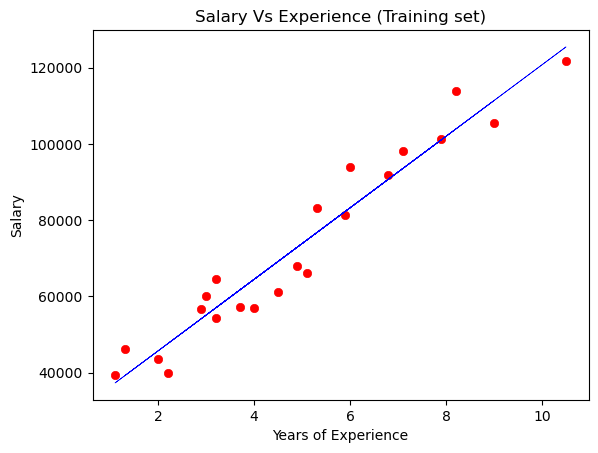

In [23]:
#visualising the traing set results
plt.scatter(x_train,y_train,c="red",lw=0.5)
plt.plot(x_train,regressor.predict(x_train),c="blue",lw=0.5)
plt.title("Salary Vs Experience (Training set)")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

Plot the same kind of graph for test results

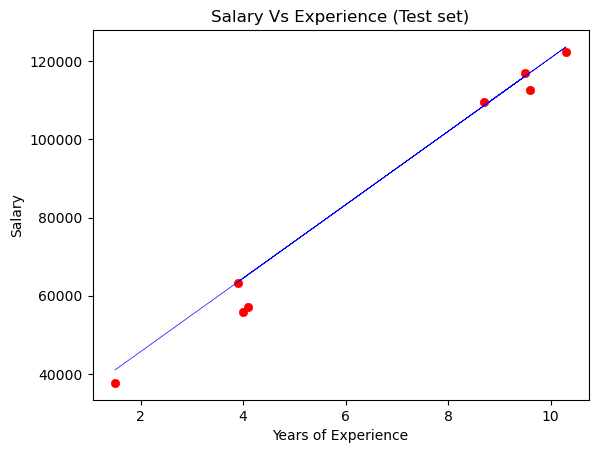

In [24]:
# visualising the test set results
plt.scatter(x_test,y_test,c="red",lw=0.5)
plt.plot(x_test,regressor.predict(x_test),c="blue",lw=0.5)
plt.title("Salary Vs Experience (Test set)")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

Predict the salary for


*   person A = 9,33 years experience
*   person B = 3,1 years experience



In [25]:
# your code here
data=np.array([9.33,3.1])
y_pred=regressor.predict(data.reshape(-1,1))
print(y_pred)

[[114499.39020659]
 [ 56063.79384177]]


### Now, do the same for Car Price dataset, predict the price using other features and linear regression algorithm.

In [26]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import linear_model

# Import du jeu de données
file = "ex02_car_price/CarPrice.csv"
datasetCP = pd.read_csv(url+file,delimiter=',')

# X et y sous forme DataFrame / Series directement
X = datasetCP[['horsepower']]   # DataFrame 2D
y = datasetCP['price']          # Series 1D

print(X.shape)
print(y.shape)

#Séparation des données en deux jeux entrainement et validation (75-25)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

print("X_train shape {}, y_train shape {}".format(X_train.shape, y_train.shape))
print("X_test shape {}, y_test shape {}".format(X_test.shape, y_test.shape))

#Essai du modèle de régression linéaire simple sur le jeu d'entrainement
regressor = linear_model.LinearRegression()
regressor.fit(X_train, y_train)

#Prédiction des résultats sur le jeu de validation
y_pred = regressor.predict(X_test)

print(y_pred)


(205, 1)
(205,)
X_train shape (153, 1), y_train shape (153,)
X_test shape (52, 1), y_test shape (52,)
[ 7291.27398919 21767.58907632 14200.42437169  4001.20237848
 12555.38856633 15187.4458549   7291.27398919  6304.25250598
 22425.60339847  8607.30263348 16009.96375758 43482.06170702
 12719.89214687  7949.28831133  7620.28115026 15187.4458549
 10910.35276097 14200.42437169 10252.33843883  6304.25250598
 15187.4458549  11732.87066365 10910.35276097 15187.4458549
 22590.106979    7455.77756973  7620.28115026 11732.87066365
  7620.28115026  7455.77756973 10087.8348583  10581.3455999
 19629.04252936 11239.35992205  7455.77756973 26044.68217025
 10910.35276097 22425.60339847  7291.27398919 26373.68933132
  7620.28115026 15022.94227436 21603.08549579 14200.42437169
 14364.92795222  7291.27398919  7291.27398919 19958.04969043
 14364.92795222 10087.8348583  19135.53178775  5152.72744223]


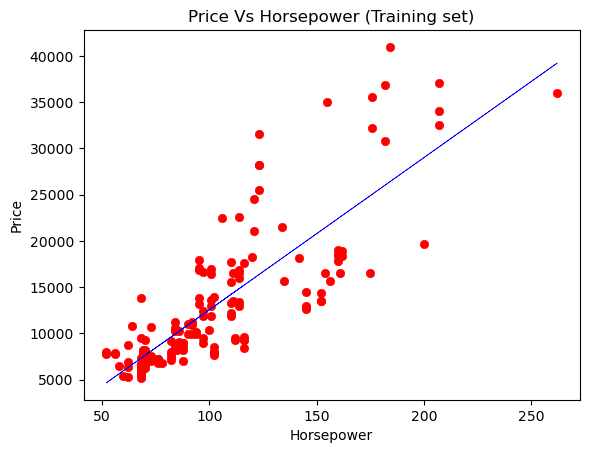

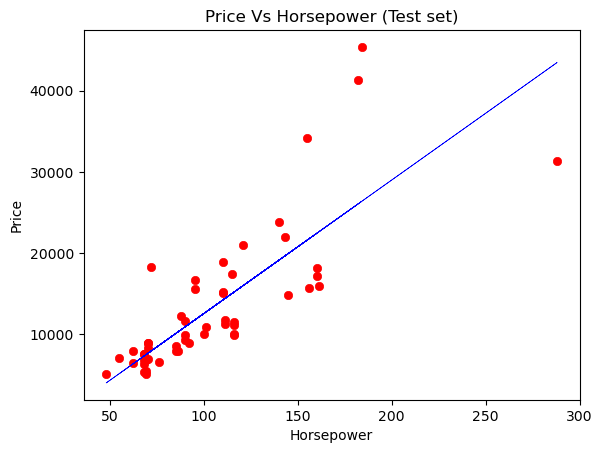

In [27]:
#visualising the traing set results
plt.scatter(X_train,y_train,c="red",lw=0.5)
plt.plot(X_train,regressor.predict(X_train),c="blue",lw=0.5)
plt.title("Price Vs Horsepower (Training set)")
plt.xlabel("Horsepower")
plt.ylabel("Price")
plt.show()

# visualising the test set results
plt.scatter(X_test,y_test,c="red",lw=0.5)
plt.plot(X_test,regressor.predict(X_test),c="blue",lw=0.5)
plt.title("Price Vs Horsepower (Test set)")
plt.xlabel("Horsepower")
plt.ylabel("Price")
plt.show()

# 3. Using Random Forest in Industrial Oil & Gas Data

Let's start by importing the librairies we'll use

In [28]:
# your code here
# Importing the libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

Import the dataset

In [29]:
# your code here
dataset_in=pd.read_csv(url+"ex3_inputs.csv",delimiter=';',decimal=',')
dataset_out=pd.read_csv(url+"ex3_outputs.csv",delimiter=';',decimal=',')

Analyze the dataset

*   show the first 10 rows
*   the number of samples
*   the number of variables
*   the type of inputs columns





In [30]:
# your code here
display(dataset_in.head(10)) #montre les 10 premières lignes
display(dataset_out.head(10)) #montre les 10 premières lignes
print("")
print("Shape de in:",dataset_in.shape,"Shape de out:",dataset_out.shape)
print("")
print(f"Liste des {len(list(dataset_in.columns))} variables de in  :",list(dataset_in.columns),"\n")
print(f"Liste des {len(list(dataset_out.columns))} variables de out :",list(dataset_out.columns))
print("")
print(dataset_in.dtypes)
print(dataset_out.dtypes)

,Flow,Steam,pressure,temperature,compo1,compo2,compo3,compo4,compo5,compo6,compo7,compo8,compo9,compo10,compo11
0,15.280256,0.3979,2.510542,811.8885,0.05,0.921,60.327,31.2,1.452,4.407,0.0,1.012,0.611,0.02,0.0
1,12.633184,0.4058,2.188879,827.0906,0.05,0.921,60.327,31.2,1.452,4.407,0.0,1.012,0.611,0.02,0.0
2,13.760800,0.3204,2.418358,840.8478,0.05,0.921,60.327,31.2,1.452,4.407,0.0,1.012,0.611,0.02,0.0
3,12.940096,0.4634,2.880259,800.8063,0.05,0.921,60.327,31.2,1.452,4.407,0.0,1.012,0.611,0.02,0.0
4,15.645024,0.3515,2.637050,818.3336,0.05,0.921,60.327,31.2,1.452,4.407,0.0,1.012,0.611,0.02,0.0
5,17.914848,0.3281,2.203589,840.5659,0.05,0.921,60.327,31.2,1.452,4.407,0.0,1.012,0.611,0.02,0.0
6,12.314208,0.4071,2.817495,816.8601,0.05,0.921,60.327,31.2,1.452,4.407,0.0,1.012,0.611,0.02,0.0
7,17.671680,0.3495,2.710601,836.5905,0.05,0.921,60.327,31.2,1.452,4.407,0.0,1.012,0.611,0.02,0.0
8,12.778784,0.3462,2.333039,837.0897,0.05,0.921,60.327,31.2,1.452,4.407,0.0,1.012,0.611,0.02,0.0
9,17.247232,0.3266,2.125135,836.5424,0.05,0.921,60.327,31.2,1.452,4.407,0.0,1.012,0.611,0.02,0.0


,DUTY,ΔP,COKING_RATE,output1,output2,output3,output4,output5,output6,output7,...,output38,output39,output40,output41,output42,output43,output44,output45,output46,output47
0,10.904623,0.412280,NaN,0.885339,0.066723,20.0513,0.251009,24.3451,3.48087,0.683737,...,0,0.238065,0,0,0,0.264515,0.243783,0.022718,0.210703,0.827901
1,9.713934,0.344329,NaN,0.996769,0.089552,21.8120,0.389097,27.5252,3.28956,0.887487,...,0,0.173564,0,0,0,0.300158,0.387762,0.014869,0.274740,1.267333
2,10.642846,0.314846,2.62825,1.041730,0.093984,24.3367,0.430423,28.5975,3.55130,0.863436,...,0,0.138672,0,0,0,0.375756,0.667877,0.012495,0.426145,2.251385
3,8.953984,0.296776,NaN,0.843026,0.072154,20.1308,0.193568,23.1585,3.73503,0.567166,...,0,0.267621,0,0,0,0.289546,0.241563,0.028683,0.230845,0.859737
4,11.279611,0.379943,1.84445,0.913419,0.069921,21.5062,0.266726,25.2562,3.71629,0.695148,...,0,0.221736,0,0,0,0.319761,0.343949,0.022128,0.286192,1.195240
5,14.021389,0.558254,3.03094,1.020210,0.080558,22.1514,0.453481,28.2130,3.31290,0.971674,...,0,0.157953,0,0,0,0.294808,0.424860,0.013049,0.282255,1.373255
6,8.951304,0.255044,1.52262,0.931909,0.089243,22.7553,0.262988,25.7298,3.87962,0.662472,...,0,0.208678,0,0,0,0.373181,0.449474,0.021758,0.365583,1.597384
7,13.506356,0.465374,2.80444,0.992038,0.090192,23.1856,0.372002,27.3729,3.67260,0.816518,...,0,0.172702,0,0,0,0.353670,0.513464,0.016274,0.365351,1.752699
8,9.897558,0.299231,2.31661,1.036140,0.095761,23.8360,0.425359,28.5251,3.47883,0.876676,...,0,0.144043,0,0,0,0.362563,0.604120,0.012836,0.393014,2.019633
9,13.351984,0.536447,2.75345,1.005340,0.075024,21.6498,0.429978,27.8052,3.27647,0.956414,...,0,0.166305,0,0,0,0.280882,0.377791,0.013620,0.257518,1.216430



Shape de in: (4880, 15) Shape de out: (4880, 50)

Liste des 15 variables de in  : ['Flow', 'Steam', 'pressure', 'temperature', 'compo1', 'compo2', 'compo3', 'compo4', 'compo5', 'compo6', 'compo7', 'compo8', 'compo9', 'compo10', 'compo11'] 

Liste des 50 variables de out : ['DUTY', 'ΔP', 'COKING_RATE', 'output1', 'output2', 'output3', 'output4', 'output5', 'output6', 'output7', 'output8', 'output9', 'output10', 'output11', 'output12', 'output13', 'output14', 'output15', 'output16', 'output17', 'output18', 'output19', 'output20', 'output21', 'output22', 'output23', 'output24', 'output25', 'output26', 'output27', 'output28', 'output29', 'output30', 'output31', 'output32', 'output33', 'output34', 'output35', 'output36', 'output37', 'output38', 'output39', 'output40', 'output41', 'output42', 'output43', 'output44', 'output45', 'output46', 'output47']

Flow           float64
Steam          float64
pressure       float64
temperature    float64
compo1         float64
compo2         float64
co

Clean the data using the following rule: erase lines where there is any blanc in the output

In [31]:
# your code here
rows_with_nan = dataset_out[dataset_out.isna().any(axis=1)]
idx_nan = dataset_out.index[dataset_out.isna().any(axis=1)]
print(idx_nan)
dataset_out=dataset_out.dropna()



Index([   0,    1,    3,   12,   15,   16,   17,   18,   20,   22,
       ...
       4836, 4839, 4840, 4844, 4857, 4859, 4861, 4862, 4871, 4876],
      dtype='int64', length=1783)


In [32]:
dataset_in=dataset_in.drop(idx_nan)

Assign your inputs and outputs to your X and y variables

In [33]:
# assisgn your dataset to your X and y variables
X = dataset_in.copy()
y = dataset_out.copy()

Split the dataset into train and test

In [34]:
# import model function to slipt the dataset
X_train,X_test,y_train,y_test =train_test_split(X,y,test_size=0.25,random_state=0)

Training the model

In [35]:
# import the function "RandomForestRegressor" from sklearn to train the model
from sklearn.ensemble import RandomForestRegressor
reg = RandomForestRegressor(n_estimators=500) # 500 is an sampling number, we should not change it from a run to another

In [36]:
# fit the model using the regressor created
reg.fit(X_train,y_train)

RandomForestRegressor(n_estimators=500)

Validate the model with test dataset

In [37]:
# calculating the output prediction "y_pred" using the test dataset "X_test"
y_pred_rf=reg.predict(X_test)

In [38]:
# calculate the score of the trained model
rf_score=reg.score(X_test,y_test)
print(rf_score)


0.921328432848044


In [39]:
# preparation to be able to plot a scatter plot using Pandas
# you don't need to change it
y_pred_rf = pd.DataFrame(y_pred_rf,index=X_test.index, columns=y_test.columns)
y_pred_train = pd.DataFrame(reg.predict(X_train),index=X_train.index, columns=y_test.columns)
y_test_actual = pd.DataFrame(y_test,index=X_test.index, columns=y_test.columns)

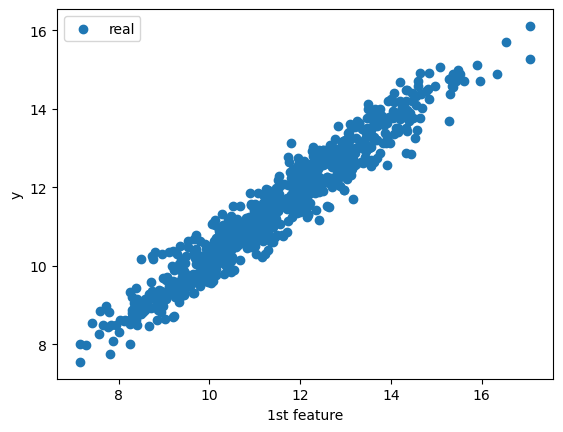

In [40]:
# plot the prediction vs the real y for the test dataset
# in the following formula we plot forthe first variable
plt.scatter(y_test.iloc[:,0],y_pred_rf.iloc[:,0], label='real')
plt.xlabel("1st feature")
plt.ylabel("y")
plt.legend(loc='best')

Adapt the previous code to plot the prediction vs real y for other 2 outputs

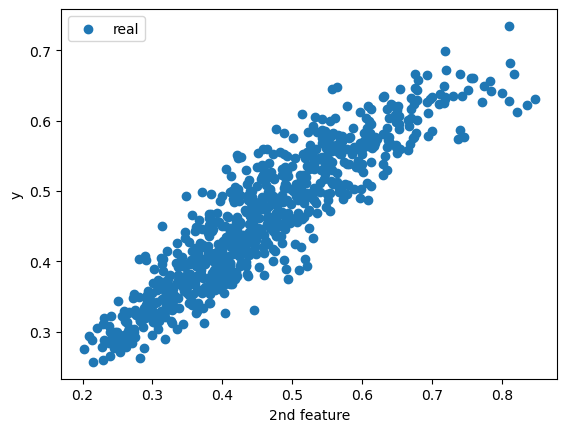

In [41]:
# your code here
plt.scatter(y_test.iloc[:,1],y_pred_rf.iloc[:,1], label='real')
plt.xlabel("2nd feature")
plt.ylabel("y")
plt.legend(loc='best')

In [42]:
# your code here

Calculate y_pred for these two sample points


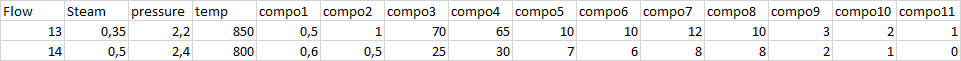

In [43]:
# your code here
data = {'Flow': [13, 14],
        'Steam': [0.35,0.5],
        'pressure': [2.2,2.4],
        'temperature': [850,800],
        'compo1': [0.5,0.6],
        'compo2': [1,0.5],
        'compo3': [70,25],
        'compo4': [65,30],
        'compo5': [10,7],
        'compo6': [10,6],
        'compo7': [12,8],
        'compo8': [10,8],
        'compo9': [3,2],
        'compo10': [2,1],
        'compo11': [1,0],
        }
df_sample_in = pd.DataFrame(data)
display(df_sample_in)

,Flow,Steam,pressure,temperature,compo1,compo2,compo3,compo4,compo5,compo6,compo7,compo8,compo9,compo10,compo11
0,13,0.35,2.2,850,0.5,1.0,70,65,10,10,12,10,3,2,1
1,14,0.50,2.4,800,0.6,0.5,25,30,7,6,8,8,2,1,0


In [44]:
# your code here
y_pred_rfs=reg.predict(df_sample_in)

df_sample_out_rfs = pd.DataFrame(y_pred_rfs, columns=dataset_out.columns)
display(df_sample_out_rfs)

,DUTY,ΔP,COKING_RATE,output1,output2,output3,output4,output5,output6,output7,...,output38,output39,output40,output41,output42,output43,output44,output45,output46,output47
0,11.034859,0.376684,2.815368,1.097763,0.131515,23.897500,0.567301,32.133726,3.498528,0.899659,...,0.0,0.102873,0.0,0.0,0.0,0.288205,0.650899,0.008531,0.347715,2.010130
1,8.540988,0.328601,1.491923,0.867016,0.098530,20.961818,0.280039,18.377846,2.478374,0.923917,...,0.0,0.316463,0.0,0.0,0.0,0.738167,0.594708,0.033802,0.683587,2.950306


### Build a Linear regression model for the same dataset. And compare the results for these two sample points.

In [45]:
regressor=linear_model.LinearRegression()
regressor.fit(X_train,y_train)

df_sample_out_lrs = regressor.predict(df_sample_in)

df_sample_out_lrs = pd.DataFrame(df_sample_out_lrs, columns=dataset_out.columns)
display(df_sample_out_lrs)



,DUTY,ΔP,COKING_RATE,output1,output2,output3,output4,output5,output6,output7,...,output38,output39,output40,output41,output42,output43,output44,output45,output46,output47
0,1.534061e+08,618944.170442,8.757177e+07,-8.113788e+07,2.827083e+06,1.951387e+08,1.410287e+06,7.810716e+08,-3.843489e+08,3.499865e+07,...,0.0,1.180412e+07,0.0,0.0,0.0,-8.558745e+06,2.993097e+07,4.709160e+06,-8.717547e+07,-5.034336e+08
1,-2.160392e+07,-87164.448559,-1.233259e+07,1.142652e+07,-3.981335e+05,-2.748104e+07,-1.986082e+05,-1.099970e+08,5.412725e+07,-4.928803e+06,...,0.0,-1.662355e+06,0.0,0.0,0.0,1.205315e+06,-4.215130e+06,-6.631835e+05,1.227678e+07,7.089775e+07


In [46]:
from sklearn.metrics import mean_squared_error

y_pred_lr = regressor.predict(X_test)
y_pred_lr = pd.DataFrame(y_pred_lr,index=X_test.index, columns=y_test.columns)

mse_rf_global = mean_squared_error(y_test_actual, y_pred_rf)
mse_lr_global = mean_squared_error(y_test_actual, y_pred_lr)

rmse_rf_global = np.sqrt(mse_rf_global)
rmse_lr_global = np.sqrt(mse_lr_global)

print("RMSE RF :", rmse_rf_global)
print("RMSE LR :", rmse_lr_global)


RMSE RF : 0.20186303750857093
RMSE LR : 0.11815056381927555


# 4. EDA using Tokyo 2021 Olympics data

In [47]:
# Import library
import pandas as pd

Import the dataset

In [48]:
import warnings
warnings.filterwarnings('ignore')
url = "https://raw.githubusercontent.com/Demosthene-OR/Student-AI-and-Data-Management/main/data_80/tokyo_data/"
gender=pd.read_excel(url+"EntriesGender.xlsx")
medal=pd.read_excel(url+"Medals.xlsx")
teams=pd.read_excel(url+"Teams.xlsx")
coaches=pd.read_excel(url+"Coaches.xlsx")
athletes=pd.read_excel(url+"Athletes.xlsx")

Print the data_80 to analyze them

Use some functions as info and describe

In [49]:
athletes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11085 entries, 0 to 11084
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Name        11085 non-null  object
 1   NOC         11085 non-null  object
 2   Discipline  11085 non-null  object
dtypes: object(3)
memory usage: 259.9+ KB


In [50]:
athletes.describe()

,Name,NOC,Discipline
count,11085,11085,11085
unique,11062,206,46
top,CHEN Yang,United States of America,Athletics
freq,2,615,2068


In [51]:
athletes.head()

,Name,NOC,Discipline
0,AALERUD Katrine,Norway,Cycling Road
1,ABAD Nestor,Spain,Artistic Gymnastics
2,ABAGNALE Giovanni,Italy,Rowing
3,ABALDE Alberto,Spain,Basketball
4,ABALDE Tamara,Spain,Basketball


Verify NaN / null values

In [52]:
medal.isnull().sum()

Rank             0
Team/NOC         0
Gold             0
Silver           0
Bronze           0
Total            0
Rank by Total    0
dtype: int64

In [53]:
medal.Gold.describe()

count    93.000000
mean      3.655914
std       7.022471
min       0.000000
25%       0.000000
50%       1.000000
75%       3.000000
max      39.000000
Name: Gold, dtype: float64

In [54]:
medal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93 entries, 0 to 92
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Rank           93 non-null     int64 
 1   Team/NOC       93 non-null     object
 2   Gold           93 non-null     int64 
 3   Silver         93 non-null     int64 
 4   Bronze         93 non-null     int64 
 5   Total          93 non-null     int64 
 6   Rank by Total  93 non-null     int64 
dtypes: int64(6), object(1)
memory usage: 5.2+ KB


Let's plot some graphs, for this, import a new library

In [55]:
import matplotlib.pyplot as plt

Let's plot the top 10 countries with golden medals

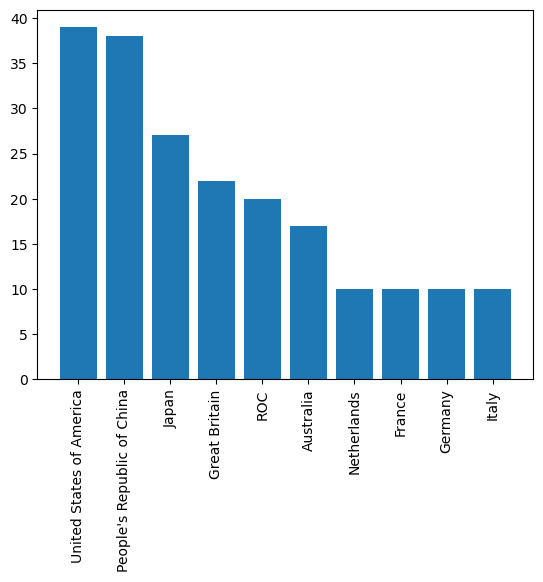

In [56]:
top_10_gold = medal.sort_values('Gold', ascending=False).head(10)
plt.bar(top_10_gold['Team/NOC'], top_10_gold['Gold'])
plt.xticks(rotation=90)
plt.show()

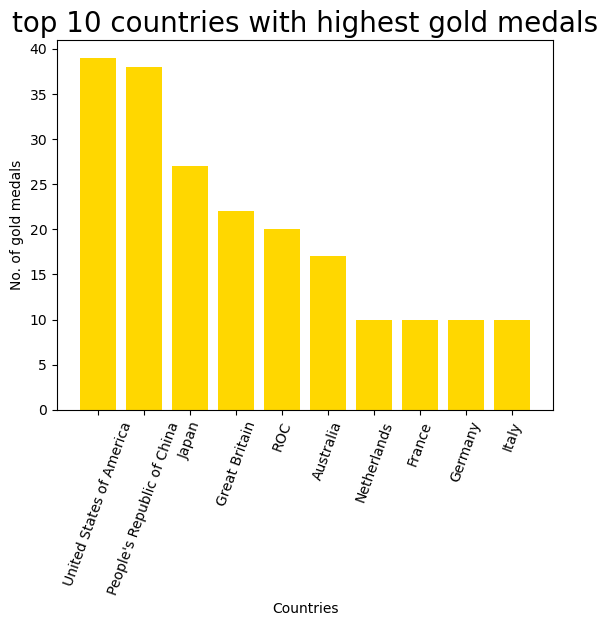

In [57]:
top_10_gold = medal.sort_values('Gold', ascending=False).head(10)
plt.bar(top_10_gold['Team/NOC'], top_10_gold['Gold'], color='gold')
# title
plt.title('top 10 countries with highest gold medals', fontsize=20)
# labels
plt.xlabel('Countries')
# rotating labels
plt.xticks(rotation=70)
plt.ylabel('No. of gold medals')
plt.show()

Also plot the Top 10 silver medals

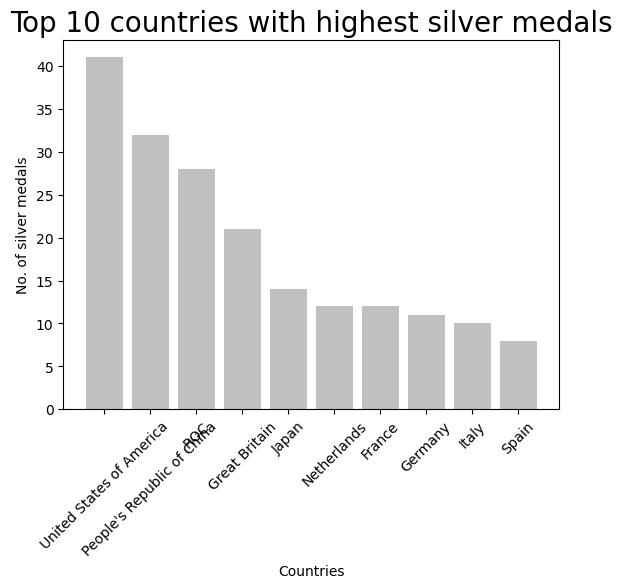

In [58]:
top_10_silver = medal.sort_values('Silver', ascending=False).head(10)
plt.bar(top_10_silver['Team/NOC'], top_10_silver['Silver'], color='Silver')
# title
plt.title('Top 10 countries with highest silver medals', fontsize=20)
plt.xlabel('Countries')
plt.xticks(rotation=45)
plt.ylabel('No. of silver medals')
plt.show()

Division between women and men among the athleths

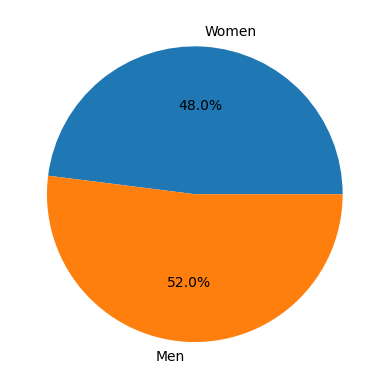

In [59]:
fem = sum(gender['Female'])
male = sum(gender['Male'])
series = [fem, male]
names=['Women', 'Men']
plt.pie(series, labels=names, autopct='%1.1f%%')
plt.show()

# 5. Clients churn prediction | Comparing different models

Importing librarires

In [60]:
# import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
%matplotlib inline

from sklearn.preprocessing import LabelEncoder, OneHotEncoder

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score

import warnings
warnings.filterwarnings("ignore")

In [62]:
# Read csv file
url = "https://raw.githubusercontent.com/Demosthene-OR/Student-AI-and-Data-Management/main/data_80/telecom_churn_data/"
dataset_in = pd.read_csv(url+"telecom_churn.csv")


**Analyze the dataset**

* use info() function
* use description function
* number of rows and columns
* is any NaN?
* variables types

Add your code below.



In [63]:
dataset_in.head(10)

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0,128,1,1,2.70,1,265.1,110,89.0,9.87,10.0
1,0,107,1,1,3.70,1,161.6,123,82.0,9.78,13.7
2,0,137,1,0,0.00,0,243.4,114,52.0,6.06,12.2
3,0,84,0,0,0.00,2,299.4,71,57.0,3.10,6.6
4,0,75,0,0,0.00,3,166.7,113,41.0,7.42,10.1
5,0,118,0,0,0.00,0,223.4,98,57.0,11.03,6.3
6,0,121,1,1,2.03,3,218.2,88,87.3,17.43,7.5
7,0,147,0,0,0.00,0,157.0,79,36.0,5.16,7.1
8,0,117,1,0,0.19,1,184.5,97,63.9,17.58,8.7
9,0,141,0,1,3.02,0,258.6,84,93.2,11.10,11.2


In [64]:
dataset_in.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Churn            3333 non-null   int64  
 1   AccountWeeks     3333 non-null   int64  
 2   ContractRenewal  3333 non-null   int64  
 3   DataPlan         3333 non-null   int64  
 4   DataUsage        3333 non-null   float64
 5   CustServCalls    3333 non-null   int64  
 6   DayMins          3333 non-null   float64
 7   DayCalls         3333 non-null   int64  
 8   MonthlyCharge    3333 non-null   float64
 9   OverageFee       3333 non-null   float64
 10  RoamMins         3333 non-null   float64
dtypes: float64(5), int64(6)
memory usage: 286.6 KB


In [65]:
dataset_in.describe()

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,0.144914,101.064806,0.903090,0.276628,0.816475,1.562856,179.775098,100.435644,56.305161,10.051488,10.237294
std,0.352067,39.822106,0.295879,0.447398,1.272668,1.315491,54.467389,20.069084,16.426032,2.535712,2.791840
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,0.000000,0.000000
25%,0.000000,74.000000,1.000000,0.000000,0.000000,1.000000,143.700000,87.000000,45.000000,8.330000,8.500000
50%,0.000000,101.000000,1.000000,0.000000,0.000000,1.000000,179.400000,101.000000,53.500000,10.070000,10.300000
75%,0.000000,127.000000,1.000000,1.000000,1.780000,2.000000,216.400000,114.000000,66.200000,11.770000,12.100000
max,1.000000,243.000000,1.000000,1.000000,5.400000,9.000000,350.800000,165.000000,111.300000,18.190000,20.000000


In [66]:
dataset_in.shape

(3333, 11)

In [67]:
dataset_in.isnull().sum()

Churn              0
AccountWeeks       0
ContractRenewal    0
DataPlan           0
DataUsage          0
CustServCalls      0
DayMins            0
DayCalls           0
MonthlyCharge      0
OverageFee         0
RoamMins           0
dtype: int64

In [68]:
dataset_in.dtypes

Churn                int64
AccountWeeks         int64
ContractRenewal      int64
DataPlan             int64
DataUsage          float64
CustServCalls        int64
DayMins            float64
DayCalls             int64
MonthlyCharge      float64
OverageFee         float64
RoamMins           float64
dtype: object

**Plot some graphs to analyze the clients churn rate**

Text(0.5, 1.0, 'Customer Churn Count')

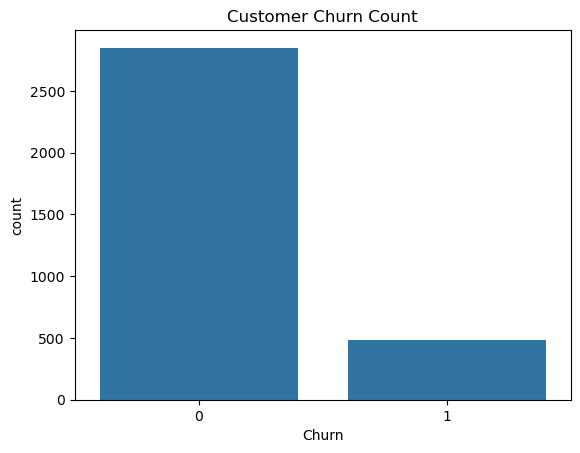

In [69]:
sns.countplot(x=dataset_in['Churn'])
plt.title('Customer Churn Count')

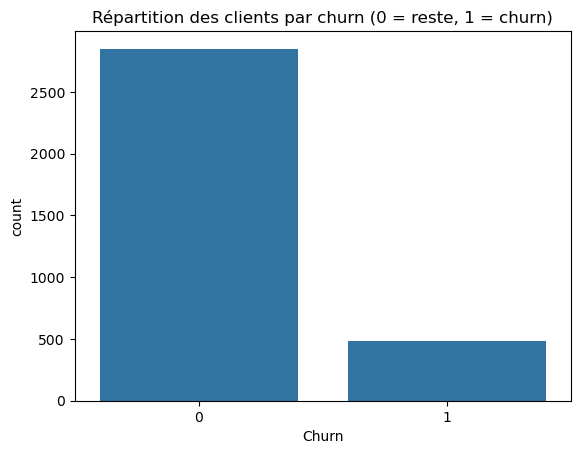

Churn
0    0.855086
1    0.144914
Name: proportion, dtype: float64

In [70]:
sns.countplot(x='Churn', data=dataset_in)
plt.title('Répartition des clients par churn (0 = reste, 1 = churn)')
plt.show()

dataset_in['Churn'].value_counts(normalize=True)

,Churn,Pourcentage
0,0,85.508551
1,1,14.491449


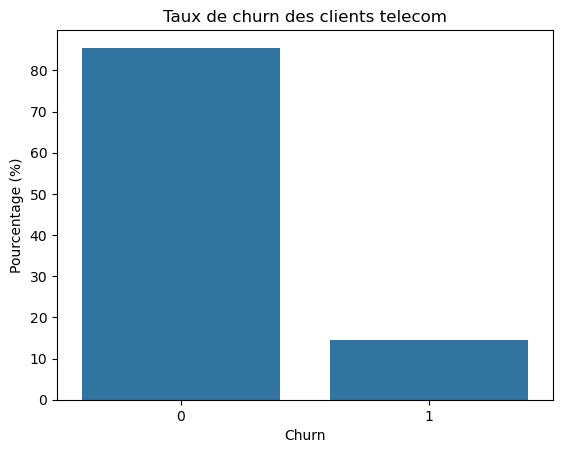

In [71]:
# Calculer les proportions avant
churn_counts = dataset_in['Churn'].value_counts()
churn_pct = churn_counts / len(dataset_in) * 100

# Créer DataFrame pour le plot
plot_data = pd.DataFrame({'Churn': churn_pct.index, 'Pourcentage': churn_pct.values})
display(plot_data)

# Tracer avec % en ordonnée
ax = sns.barplot(x='Churn', y='Pourcentage', data=plot_data)
plt.ylabel('Pourcentage (%)')
plt.title('Taux de churn des clients telecom')
plt.show()

**Attribute X and y variables**

Use functions .iloc[ ] and/or .loc[ ]

In [72]:
# assisgn your dataset to your X and y variables
X=dataset_in.iloc[:,-10:]
y=dataset_in.loc[:,['Churn']]

In [73]:
X=dataset_in.iloc[:,-10:]
y=dataset_in["Churn"]

Print X and y to verify them

In [74]:
X.head()

,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,128,1,1,2.7,1,265.1,110,89.0,9.87,10.0
1,107,1,1,3.7,1,161.6,123,82.0,9.78,13.7
2,137,1,0,0.0,0,243.4,114,52.0,6.06,12.2
3,84,0,0,0.0,2,299.4,71,57.0,3.10,6.6
4,75,0,0,0.0,3,166.7,113,41.0,7.42,10.1


In [75]:
y

0       0
1       0
2       0
3       0
4       0
       ..
3328    0
3329    0
3330    0
3331    0
3332    0
Name: Churn, Length: 3333, dtype: int64

In [76]:
np.ravel(y)

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

**Split your dataset into train and test data**

In [77]:
# import model function to slipt the dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y)

**Train the model**

In [78]:
# Instantiate the models, one per line!
log = LogisticRegression().fit(X_train, y_train)
knn = KNeighborsClassifier(n_neighbors=29).fit(X_train, y_train)
tree = DecisionTreeClassifier().fit(X_train, y_train)
rfc = RandomForestClassifier().fit(X_train, y_train)
svc = SVC(C=1,gamma=0.001).fit(X_train, y_train)

models = [log, knn, tree, rfc, svc]
models_names = ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest', 'Support Vector Machine']

In [79]:
# Calculate some performance indicators

scoring = ['accuracy','precision','recall','f1']
train_accuracy = []
train_precision = []
train_recall = []
train_f1 = []
train_std = []

train_scoring_acc = {}
train_scoring_f1 = {}
for i,model in enumerate (models):
    scores = cross_validate(model, X_train, y_train, cv=10, scoring=scoring)

    # ignore the first two columns from scoring which are fit_time and score_time
    # pay attention to the breakdown in the Cross validation section
    train_accuracy.append(scores['test_accuracy'].mean())
    train_precision.append(scores['test_precision'].mean())
    train_recall.append(scores['test_recall'].mean())
    train_f1.append(scores['test_f1'].mean())
    train_std.append(scores['test_accuracy'].std())

    train_scoring_acc[i] = scores['test_accuracy']
    train_scoring_f1[i] = scores['test_accuracy']


train_scores = pd.DataFrame(list(zip(train_accuracy,train_precision,train_recall,train_f1,train_std)),
                            index=models_names,columns=['Accuracy','Precision','Recall','F1-score','Standard Deviation'])
print('Models Training Scores')
train_scores

Models Training Scores


,Accuracy,Precision,Recall,F1-score,Standard Deviation
Logistic Regression,0.859144,0.490859,0.177143,0.254886,0.010700
KNN,0.873947,0.660449,0.171429,0.268486,0.016244
Decision Tree,0.893950,0.621138,0.637143,0.624837,0.015881
Random Forest,0.940369,0.885107,0.662857,0.754380,0.017043
Support Vector Machine,0.879949,0.752579,0.197143,0.309643,0.017368


* Accuracy: The proportion of the total number of correct predictions.
* Positive Predictive Value or Precision: The proportion of positive cases that were correctly identified.
* Negative Predictive Value: The proportion of negative cases that were correctly identified.
*  Sensitivity/Recall: The proportion of actual positive cases that are correctly identified
* Specificity: the proportion of actual negative cases that are correctly identified.


<img src="https://miro.medium.com/v2/resize:fit:1400/format:webp/0*7nWIlMw_fms-2938.png" width = '600'>


Text(0, 0.5, 'Accuracy rate')

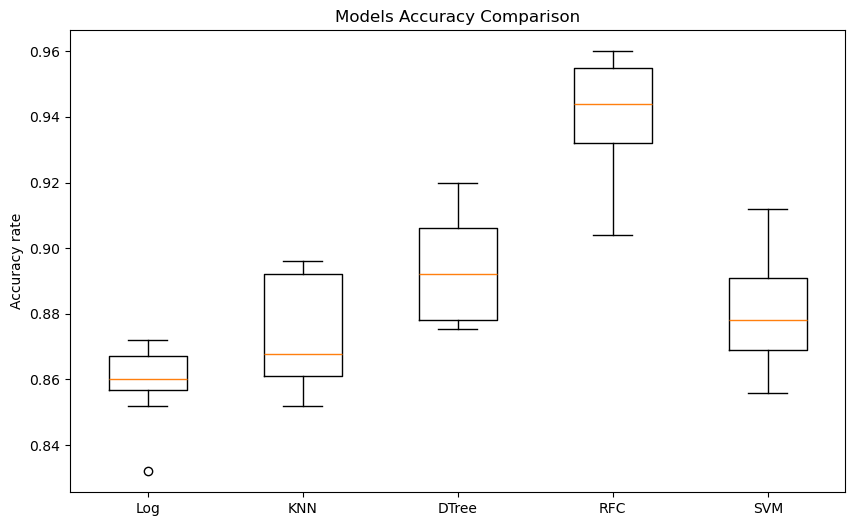

In [80]:
# Another way to verify these indicators

fig, ax = plt.subplots(figsize=(10,6))
ax.boxplot(train_scoring_acc.values())
ax.set_xticklabels(['Log','KNN','DTree','RFC','SVM'])

plt.title('Models Accuracy Comparison')
plt.ylabel('Accuracy rate')

Text(0, 0.5, 'F1 score')

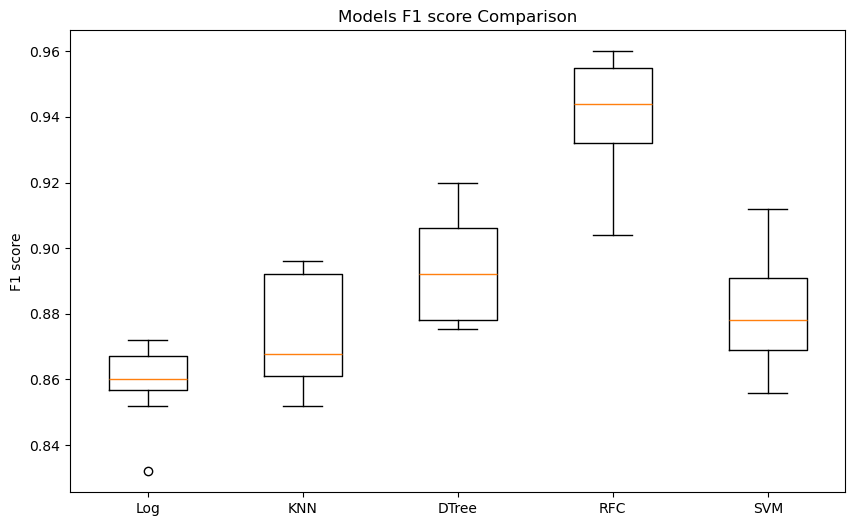

In [81]:
# Another way to verify these indicators

fig, ax = plt.subplots(figsize=(10,6))
ax.boxplot(train_scoring_f1.values())
ax.set_xticklabels(['Log','KNN','DTree','RFC','SVM'])

plt.title('Models F1 score Comparison')
plt.ylabel('F1 score')

In [82]:
best_model_name = train_scores['Accuracy'].idxmax()
best_model_index = models_names.index(best_model_name)
best_model = models[best_model_index]

print(f"Best model selected: {best_model_name}")
print(train_scores.loc[best_model_name])


Best model selected: Random Forest
Accuracy              0.940369
Precision             0.885107
Recall                0.662857
F1-score              0.754380
Standard Deviation    0.017043
Name: Random Forest, dtype: float64
